# 05 — API Setup & Deployment

**Pipeline stage:** `Maintenance Recommendation -> API / Monitoring Dashboard`

Every earlier notebook ends with a trained artifact sitting in `models_store/`. This one
shows how those artifacts actually get served: the FastAPI prediction service, exercised
**in-process** with Starlette's `TestClient` — no separate server process needed, which
makes this notebook fully self-contained and reproducible top to bottom.

### Architecture

```
 models_store/*.joblib, *.pt, champion.json
              |
              v
     ModelRegistry (api/inference.py)
       - loads each subset's champion model + conformal interval, lazily, once
       - precomputes fleet-wide predictions over the CMAPSS test set at startup
              |
              v
        FastAPI app (api/main.py)
       /health              service + which subsets are ready
       /predict             raw sensor readings -> RUL + risk + recommendation
       /fleet/{subset}      every test engine, ranked by predicted RUL
       /engine/{subset}/{unit}   full sensor history + prediction for one engine
       /models/{subset}     the comparison leaderboard + which model won
              |
              v
        React dashboard (dashboard/) <- this is what a maintenance planner actually opens
```


In [1]:
import sys
from pathlib import Path

project_root = Path.cwd()
while not (project_root / "pyproject.toml").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

import pandas as pd
import matplotlib.pyplot as plt
from starlette.testclient import TestClient

from api.main import app

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

client = TestClient(app)


C:\Users\miqba\AppData\Local\Temp\ipykernel_46944\1912068041.py:11: StarletteDeprecationWarning: Using `httpx` with `starlette.testclient` is deprecated; install `httpx2` instead.
  from starlette.testclient import TestClient


## 1. Health check

On first request, `ModelRegistry` lazily loads whichever subsets get asked for — champion
model weights, the fitted feature pipeline, and the calibrated conformal interval — and
caches them for the life of the process.


In [2]:
client.get("/health").json()


{'status': 'ok', 'available_subsets': ['FD001', 'FD002', 'FD003', 'FD004']}

## 2. Fleet monitoring — `/fleet/{subset}`

Every test-set engine, already scored by its subset's champion model, ranked by predicted
RUL — this is the payload the dashboard's fleet-overview table renders directly.


In [3]:
fleet = pd.DataFrame(client.get("/fleet/FD001").json())
fleet.head(10)


,unit_number,latest_cycle,predicted_rul,predicted_rul_lower,predicted_rul_upper,true_rul,risk_tier,recommendation,model_used
0,34,203,0.0,0.0,29.4,7.0,critical,Ground engine for inspection immediately — fai...,transformer
1,81,213,3.9,0.0,33.4,8.0,critical,Ground engine for inspection immediately — fai...,transformer
2,42,156,4.0,0.0,33.5,10.0,critical,Ground engine for inspection immediately — fai...,transformer
3,82,162,4.0,0.0,33.4,9.0,critical,Ground engine for inspection immediately — fai...,transformer
4,35,198,5.8,0.0,35.3,11.0,critical,Ground engine for inspection immediately — fai...,transformer
5,76,205,6.4,0.0,35.8,10.0,critical,Ground engine for inspection immediately — fai...,transformer
6,31,196,6.7,0.0,36.1,8.0,critical,Ground engine for inspection immediately — fai...,transformer
7,68,187,7.2,0.0,36.7,8.0,critical,Ground engine for inspection immediately — fai...,transformer
8,20,184,11.0,0.0,40.4,16.0,critical,Ground engine for inspection immediately — fai...,transformer
9,66,147,12.5,0.0,41.9,14.0,critical,Ground engine for inspection immediately — fai...,transformer


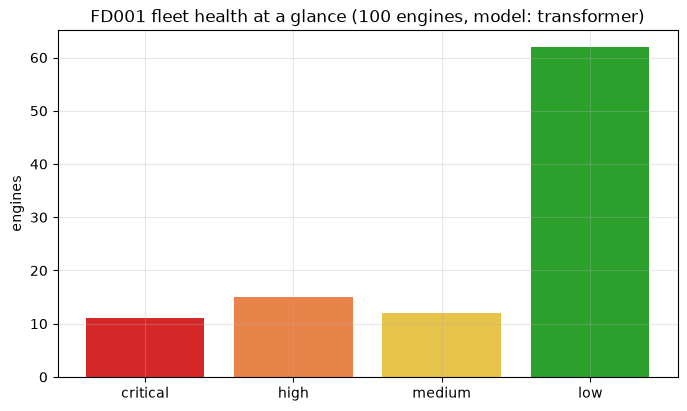

In [4]:
fig, ax = plt.subplots()
order = ["critical", "high", "medium", "low"]
counts = fleet["risk_tier"].value_counts().reindex(order)
colors = {"critical": "#d62728", "high": "#e8834a", "medium": "#e8c34a", "low": "#2ca02c"}
ax.bar(counts.index, counts.values, color=[colors[t] for t in counts.index])
ax.set_ylabel("engines")
ax.set_title(f"FD001 fleet health at a glance ({len(fleet)} engines, model: {fleet.model_used.iloc[0]})")
plt.show()


## 3. Engine drill-down — `/engine/{subset}/{unit_number}`

Full sensor history plus the same prediction/interval/recommendation as the fleet view — this
is what the dashboard shows when a planner clicks into a specific engine.


In [5]:
most_critical_unit = int(fleet.iloc[0]["unit_number"])
engine = client.get(f"/engine/FD001/{most_critical_unit}").json()

print(f"Engine #{engine['unit_number']}: predicted RUL {engine['predicted_rul']} "
      f"({engine['predicted_rul_lower']}-{engine['predicted_rul_upper']}, 90% interval), "
      f"true RUL {engine['true_rul']}, risk={engine['risk_tier']}, model={engine['model_used']}")
print(engine["recommendation"])


Engine #34: predicted RUL 0.0 (0.0-29.4, 90% interval), true RUL 7.0, risk=critical, model=transformer
Ground engine for inspection immediately — failure risk within the next few cycles.


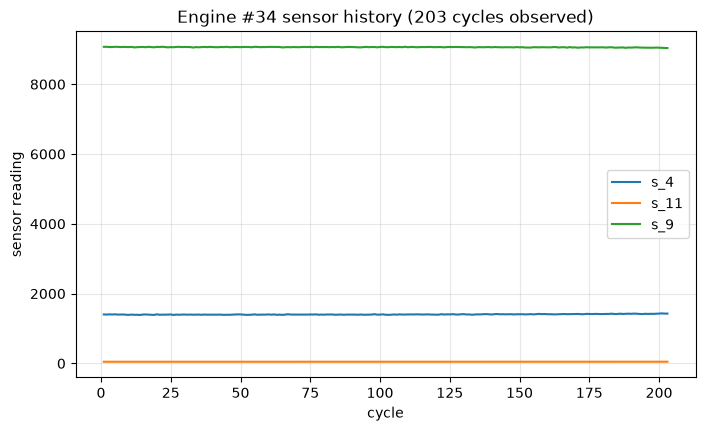

In [6]:
fig, ax = plt.subplots()
for sensor in ["s_4", "s_11", "s_9"]:
    ax.plot(engine["cycles"], engine["sensors"][sensor], label=sensor, lw=1.5)
ax.set_xlabel("cycle")
ax.set_ylabel("sensor reading")
ax.set_title(f"Engine #{engine['unit_number']} sensor history ({len(engine['cycles'])} cycles observed)")
ax.legend()
plt.show()


## 4. Live prediction from raw sensor readings — `POST /predict`

This is the endpoint a real deployment would call from an actual telemetry feed: send
whatever cycle history is available for one engine (more history gives more accurate rolling
features, but even a single reading works), get back a prediction. We'll simulate that by
replaying a real test engine's last 20 cycles as if they'd just arrived live.


In [7]:
from aerorul.data.loader import load_subset

raw = load_subset("FD001")
sample_unit = most_critical_unit
recent_readings = raw.test[raw.test.unit_number == sample_unit].tail(20)

payload = {
    "subset": "FD001",
    "readings": recent_readings.to_dict(orient="records"),
}
response = client.post("/predict", json=payload)
response.status_code, response.json()


(200,
 {'unit_number': 34,
  'latest_cycle': 203,
  'predicted_rul': 3.2,
  'predicted_rul_lower': 0.0,
  'predicted_rul_upper': 32.6,
  'risk_tier': 'critical',
  'recommendation': 'Ground engine for inspection immediately — failure risk within the next few cycles.',
  'model_used': 'transformer'})

## 5. Model transparency — `/models/{subset}`

The same leaderboard notebook 03 built from `champion.json`, served live — so a caller (or
the dashboard) can always see *why* a given model was picked, not just trust it blindly.


In [8]:
comparison = client.get("/models/FD001").json()
print("champion:", comparison["champion"])
pd.DataFrame(comparison["metrics"]).T.sort_values("nasa_score")


champion: transformer


,rmse,mae,nasa_score
transformer,16.044705,12.159575,438.621821
tcn,17.503834,12.404024,557.841716
lstm,17.709078,13.502237,747.343124
xgboost,18.980691,13.819111,1138.218327
survival,27.761542,22.864612,1527.096446


## 6. From here to production

- **CORS** is configured (`api/main.py`) to allow the dashboard's dev server origins —
  needed since the API and dashboard run as separate processes/ports.
- **Docker**: `api/Dockerfile` builds the FastAPI service with `uv`; `dashboard/Dockerfile`
  multi-stage builds the React app and serves it via nginx. `docker-compose.yml` wires both
  together with `models_store/` mounted read-only into the API container (train once,
  deploy anywhere the artifacts get copied to).
- **Experiment tracking**: every training run (`scripts/train*.py`) logs params/metrics/
  artifacts to MLflow (`mlflow.db`), independent of what's currently the champion in
  `champion.json` — the losing runs stay inspectable, they just don't get served.
- **Re-deploying a new champion** is just: retrain -> `scripts/compare_models.py` ->
  restart the API process. `ModelRegistry` reads `champion.json` fresh on next startup.

```bash
uv run python scripts/train.py --subset all           # regenerate/refresh models_store/
docker compose up --build                              # API on :8000, dashboard on :5173
```


## Summary

- The entire prediction service is exercised here without a separate running process —
  `TestClient` drives the real FastAPI app in-process, so every response above is genuine,
  not mocked.
- `/fleet` and `/engine` are what power the dashboard; `/predict` is the integration point
  for a real telemetry feed; `/models` keeps the champion-selection decision auditable
  rather than opaque.
- This closes the loop the whole project was built around:

  `Raw Sensor Data -> Health Indicator -> RUL Prediction -> Failure Risk -> Maintenance Recommendation -> API / Monitoring Dashboard`
